https://www.kaggle.com/datasets/rezaunderfit/instagram-fake-and-real-accounts-dataset

The purpose of this data would be to cluster if an instagram account is fake or not. It will use factors like has extranal links in bio, is private, and etc. to make these clusters

Target- is_fake

In [31]:
import pandas as pd
data = pd.read_csv('/content/final-v1.csv')
data

,edge_followed_by,edge_follow,username_length,username_has_number,full_name_has_number,full_name_length,is_private,is_joined_recently,has_channel,is_business_account,has_guides,has_external_url,is_fake
0,0.001,0.257,13,1,1,13,0,0,0,0,0,0,1
1,0.000,0.958,9,1,0,0,0,1,0,0,0,0,1
2,0.000,0.253,12,0,0,0,0,0,0,0,0,0,1
3,0.000,0.977,10,1,0,0,0,0,0,0,0,0,1
4,0.000,0.321,11,0,0,11,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
780,0.000,0.020,9,0,0,14,1,0,0,0,0,0,0
781,0.000,0.081,18,1,0,15,1,0,0,0,0,0,0
782,0.000,0.115,9,0,0,8,1,0,0,0,0,0,0
783,0.000,0.049,12,0,0,28,1,0,0,0,0,0,0


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edge_followed_by      785 non-null    float64
 1   edge_follow           785 non-null    float64
 2   username_length       785 non-null    int64  
 3   username_has_number   785 non-null    int64  
 4   full_name_has_number  785 non-null    int64  
 5   full_name_length      785 non-null    int64  
 6   is_private            785 non-null    int64  
 7   is_joined_recently    785 non-null    int64  
 8   has_channel           785 non-null    int64  
 9   is_business_account   785 non-null    int64  
 10  has_guides            785 non-null    int64  
 11  has_external_url      785 non-null    int64  
 12  is_fake               785 non-null    int64  
dtypes: float64(2), int64(11)
memory usage: 79.9 KB


In [33]:
data = data.drop(['edge_followed_by','has_channel','has_guides'], axis =1)
data

,edge_follow,username_length,username_has_number,full_name_has_number,full_name_length,is_private,is_joined_recently,is_business_account,has_external_url,is_fake
0,0.257,13,1,1,13,0,0,0,0,1
1,0.958,9,1,0,0,0,1,0,0,1
2,0.253,12,0,0,0,0,0,0,0,1
3,0.977,10,1,0,0,0,0,0,0,1
4,0.321,11,0,0,11,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
780,0.020,9,0,0,14,1,0,0,0,0
781,0.081,18,1,0,15,1,0,0,0,0
782,0.115,9,0,0,8,1,0,0,0,0
783,0.049,12,0,0,28,1,0,0,0,0


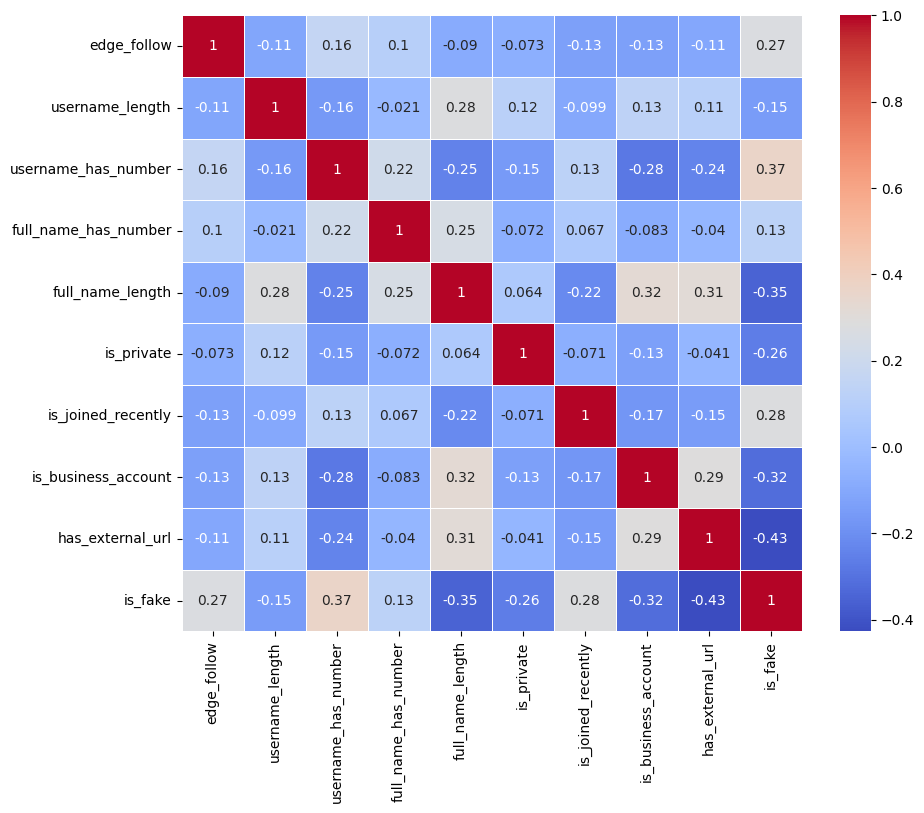

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

df = data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, cmap="coolwarm", linewidths=0.5)

plt.show()

In [35]:
features = data.drop(["is_fake"],axis=1)
labels = data["is_fake"]
features.head()

,edge_follow,username_length,username_has_number,full_name_has_number,full_name_length,is_private,is_joined_recently,is_business_account,has_external_url
0,0.257,13,1,1,13,0,0,0,0
1,0.958,9,1,0,0,0,1,0,0
2,0.253,12,0,0,0,0,0,0,0
3,0.977,10,1,0,0,0,0,0,0
4,0.321,11,0,0,11,1,0,0,0


In [36]:
from sklearn.cluster import KMeans

features = features.values
km_model = KMeans(n_clusters=2)
km_model.fit(features)

KMeans(n_clusters=2)

In [37]:
print(km_model.labels_)

[1 0 0 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0
 1 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0
 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0
 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 1 0 0 1 1 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0
 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1 0 0 1 0
 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0
 1 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1
 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0
 1 0 0 0 0 1 0 1 0 0 1 1 0 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 

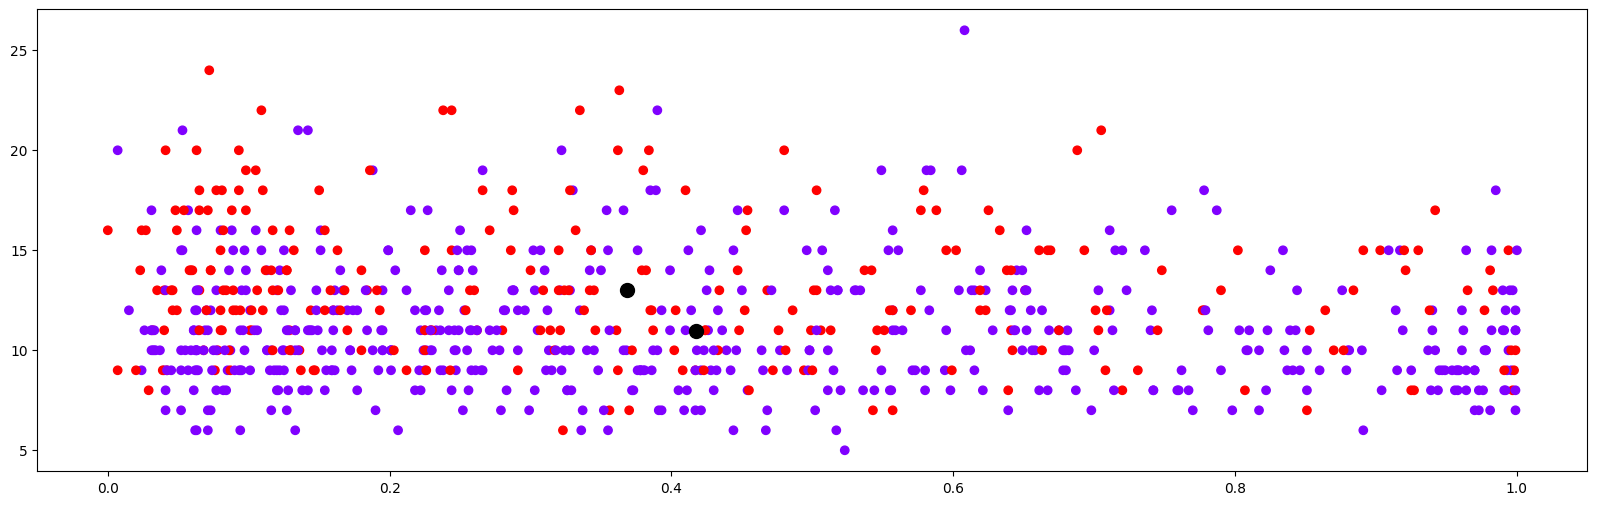

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 6))

plt.scatter(features[:,0],features[:,1],c=km_model.labels_,cmap='rainbow')
plt.scatter(km_model.cluster_centers_[:,0] , km_model.cluster_centers_[:,1],s=100,c='black' )
plt.show()

In [39]:
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
labels_num = le.fit_transform(labels)
print("ARI = ", adjusted_rand_score(labels, km_model.labels_))

ARI =  0.1325500612992094


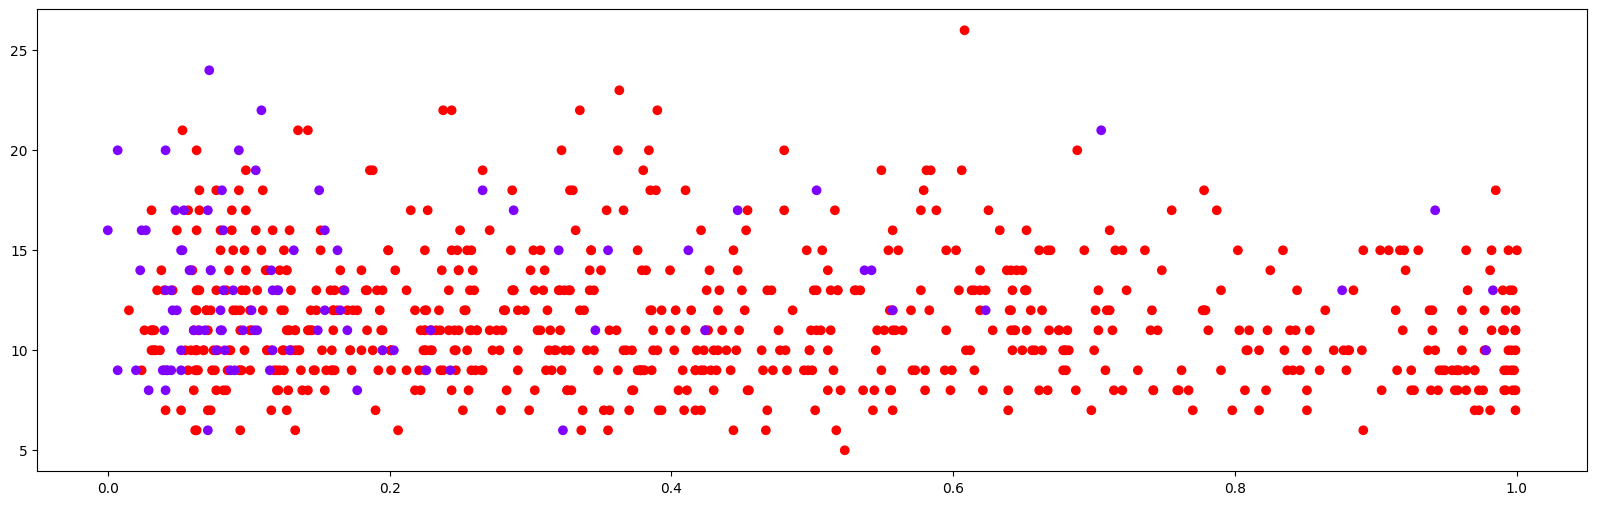

In [40]:
plt.figure(figsize=(20, 6))
plt.scatter(features[:,0], features[:,1], c= labels, cmap='rainbow')
plt.show()

In [41]:
data['is_fake'].value_counts()

,count
is_fake,
1,692
0,93


In [42]:
692/(692+93)

0.8815286624203822

ARI score is really bad and this makes sense because K-means tends to create clusters of relatively equal size. is_fake has over 80 percent 1's




In [61]:
features = data.drop(["is_fake"],axis=1)
labels = data["is_fake"]

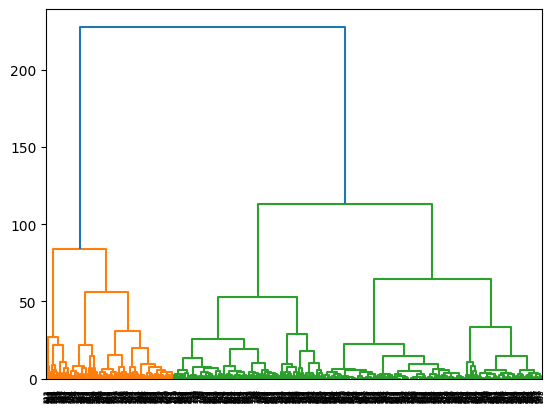

In [62]:

import scipy.cluster.hierarchy as shc
dend = shc.dendrogram(shc.linkage(features, method='ward'))


In [63]:
from sklearn.cluster import AgglomerativeClustering
features = features.values
hc_model = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
predicted_labels = hc_model.fit_predict(features)

In [64]:
print(hc_model.labels_)

[1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0
 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 1 0 0
 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0
 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 1 0 0 1 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0
 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 1 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1
 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0
 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 

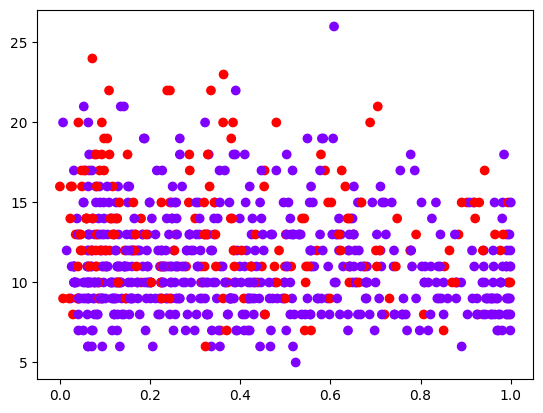

In [65]:
plt.scatter(features[:,0], features[:,1], c=hc_model.labels_, cmap='rainbow')
plt.show()

In [66]:
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
labels_num = le.fit_transform(labels)
print("ARI = ", adjusted_rand_score(labels, hc_model.labels_))

ARI =  0.1726090725153928


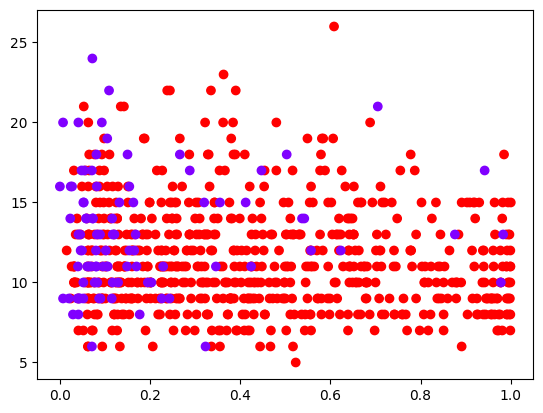

In [67]:
plt.scatter(features[:,0], features[:,1], c=labels, cmap='rainbow')
plt.show()

Both types of clustering had a very poor ARI score(less than .20). There is a lot more fake(1) data points than real(0). K-means generally has equal amount of points in each cluster so thats why API is really low. For aglomerative clustering, it doesn't necessarily make equal clusters, but the API is still how. The only conclusion I can make is there isn't enough 0's in the dataset. With more points, the model could make a better prediction, which it something I would have to do in the future.